In [ ]:
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml
from tqdm import tqdm
from weatherbenchX import aggregation, binning, time_chunks, weighting

from swissclim_evaluations.cli import prepare_datasets
from swissclim_evaluations.metrics.probabilistic import (
    CRPSEnsemble,
    SpreadSkillRatio,
    run_probabilistic_wbx,
)
from swissclim_evaluations.plots import (
    probabilistic_wbx as prob_wbx_plots,
)

In [2]:
# Use config to drive paths and selections; locate it relative to notebook
cfg_path = None
for base in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    candidate = base / "config" / "example_config.yaml"
    if candidate.is_file():
        cfg_path = candidate
        break
if cfg_path is None:
    raise FileNotFoundError(
        "Could not find config/example_config.yaml in cwd, parent, or grandparent directories."
    )

with open(cfg_path, "r") as f:
    cfg = yaml.safe_load(f)

EVAL_DATASET = "ml"

ds_targets, ds_predictions, ds_std, ds_predictions_std = prepare_datasets(cfg)

# Try to load land/sea mask; fallback to None if unavailable
try:
    from swissclim_evaluations.data import land_sea_mask

    lsm = land_sea_mask(path=cfg["paths"]["nwp"]).compute()
    # Align mask to the pipeline grid
    lsm = lsm.sel(
        latitude=ds_targets["latitude"], longitude=ds_targets["longitude"]
    )  # type: ignore[index]
except Exception:
    lsm = None

/capstor/store/cscs/swissai/a122/sadamov/SwissClim_Evaluations/src/swissclim_evaluations/data.py:101: RuntimeWarning: Rechunking ml to policy {'init_time': 1, 'lead_time': 1, 'level': 1, 'ensemble': -1, 'latitude': -1, 'longitude': -1}. This may increase memory usage and runtime.
  warnings.warn(


In [3]:
ds_targets

<xarray.Dataset> Size: 8MB
Dimensions:                  (init_time: 2, lead_time: 1, latitude: 720,
                              longitude: 1440)
Coordinates:
  * init_time                (init_time) datetime64[ns] 16B 2023-01-02T12:00:...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 16B 2023-0...
Data variables:
    10m_u_component_of_wind  (latitude, longitude, init_time, lead_time) float32 8MB dask.array<chunksize=(720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    last_updated:      2024-10-17 20:04:10.783634
    valid_time_start:  1940-01-01
    valid_time_stop:   2024-07-31

In [4]:
ds_predictions

<xarray.Dataset> Size: 66MB
Dimensions:                  (init_time: 2, lead_time: 1, ensemble: 8,
                              latitude: 720, longitude: 1440)
Coordinates:
  * init_time                (init_time) datetime64[ns] 16B 2023-01-02T12:00:...
  * lead_time                (lead_time) timedelta64[ns] 8B 06:00:00
  * ensemble                 (ensemble) int64 64B 0 1 2 3 4 5 6 7
  * latitude                 (latitude) float32 3kB 90.0 89.75 ... -89.5 -89.75
  * longitude                (longitude) float32 6kB 0.0 0.25 ... 359.5 359.8
    valid_time               (init_time, lead_time) datetime64[ns] 16B dask.array<chunksize=(1, 1), meta=np.ndarray>
Data variables:
    10m_u_component_of_wind  (ensemble, latitude, longitude, init_time, lead_time) float32 66MB dask.array<chunksize=(8, 720, 1440, 1, 1), meta=np.ndarray>
Attributes:
    model:    model_ckpt-step=7300-loss_train=0.07.ckpt

In [5]:
metrics = {
    "CRPS": CRPSEnsemble(ensemble_dim="ensemble"),
    "SSR": SpreadSkillRatio(ensemble_dim="ensemble"),
}

# define spatial aggregation
weigh_by = [weighting.GridAreaWeighting()]

# Regions: prefer config if provided
regions_cfg = (
    cfg.get("plotting", {}).get("regions") if isinstance(cfg, dict) else None
)
regions = regions_cfg or {
    "global": ((-90, 90), (0, 360)),
    "tropics": ((-20, 20), (0, 360)),
    "northern-hemisphere": ((20, 90), (0, 360)),
    "southern-hemisphere": ((-90, -20), (0, 360)),
    "europe": ((35, 75), (-12.5, 42.5)),
    "north-america": ((25, 60), (360 - 120, 360 - 75)),
    "north-atlantic": ((25, 65), (360 - 70, 360 - 10)),
    "north-pacific": ((25, 60), (145, 360 - 130)),
    "east-asia": ((25, 60), (102.5, 150)),
    "ausnz": ((-45, -12.5), (120, 175)),
    "arctic": ((60, 90), (0, 360)),
    "antarctic": ((-90, -60), (0, 360)),
}

# If land/sea mask is missing, pass None (Regions can handle it by returning all-ocean/land bins as empty)
bin_by = [
    binning.Regions(regions=regions, land_sea_mask=lsm)
    if lsm is not None
    else binning.Regions(regions=regions)
]
spatial_aggregator = aggregation.Aggregator(
    reduce_dims=["latitude", "longitude"],
    bin_by=bin_by,
    weigh_by=weigh_by,
)

# define temporal aggregation (reduce along init_time)
# Optionally group by season; read from cfg if present
seasonal = (
    cfg.get("plotting", {}).get("group_by_season", False)
    if isinstance(cfg, dict)
    else False
)
if seasonal:
    bin_by = [binning.ByTimeUnit("season", "init_time")]
else:
    bin_by = None

temporal_aggregator = aggregation.Aggregator(
    reduce_dims=["init_time"],
    bin_by=bin_by,
)

In [ ]:
out_root = Path(
    cfg.get("paths", {}).get("output_root", "output/verification_esfm")
)
# Compute standardized WBX outputs (CSVs, NetCDFs, optional CRPS map)
prob_wbx_plots.run(
    ds_target=ds_targets,
    ds_prediction=ds_predictions,
    out_root=out_root,
    plotting_cfg=cfg.get("plotting", {}),
    all_cfg=cfg,
)

[probabilistic_wbx] saved output/verification_esfm/probabilistic_wbx/spread_skill_ratio.csv
[probabilistic_wbx] saved output/verification_esfm/probabilistic_wbx/crps_ensemble.csv
Saved SSR and CRPS CSVs under: output/verification_esfm/probabilistic_wbx
[probabilistic_wbx-plots] saved output/verification_esfm/probabilistic_wbx/spread_skill_ratio.csv
[probabilistic_wbx-plots] saved output/verification_esfm/probabilistic_wbx/crps_ensemble.csv
Wrote: output/verification_esfm/probabilistic_wbx/probabilistic_metrics_temporal.nc
Wrote: output/verification_esfm/probabilistic_wbx/probabilistic_metrics_spatial.nc
[probabilistic_wbx-plots] saved output/verification_esfm/probabilistic_wbx/crps_map_10m_u_component_of_wind.png


In [7]:
# Compute temporal_results (spatially aggregated per-chunk) and spatial_results
# (temporally aggregated and averaged over chunks) using WeatherBenchX

# Prepare inputs
predictions = ds_predictions
targets = ds_targets
variables = [v for v in predictions.data_vars if v in targets.data_vars]

init_times = predictions["init_time"].values
lead_times = predictions["lead_time"].values
if lead_times.dtype != "timedelta64[ns]":
    lead_times = lead_times.astype("timedelta64[ns]")

prob_cfg = cfg.get("probabilistic", {}) if isinstance(cfg, dict) else {}
init_chunk_size = prob_cfg.get("init_time_chunk_size", 20)
lead_chunk_size = prob_cfg.get("lead_time_chunk_size", 1)

# Allow overriding exact lead times from cfg (e.g., a single 6h lead)
lead_times_override = (
    prob_cfg.get("lead_times_ns") if isinstance(prob_cfg, dict) else None
)
if lead_times_override is not None:
    lead_times = np.array(lead_times_override, dtype="timedelta64[ns]")

times = time_chunks.TimeChunks(
    init_times,
    lead_times,
    init_time_chunk_size=init_chunk_size,
    lead_time_chunk_size=lead_chunk_size,
)

spatial_results = None
temporal_results_list = []

i = -1
pbar = tqdm(times, desc="Computing WBX metrics (chunked)")
for i, (init_chunk, lead_chunk) in enumerate(pbar):
    pred_chunk = predictions.sel(init_time=init_chunk, lead_time=lead_chunk)
    target_chunk = targets.sel(init_time=init_chunk, lead_time=lead_chunk)

    # Light rechunk to improve parallelization; adjust workers as needed
    workers = (
        int(cfg.get("plotting", {}).get("num_workers", 8))
        if isinstance(cfg, dict)
        else 8
    )
    pred_chunk = pred_chunk.chunk({"init_time": 1}).persist(
        scheduler="threads", num_workers=workers
    )
    target_chunk = target_chunk.chunk({"init_time": 1}).persist(
        scheduler="threads", num_workers=workers
    )

    pred_map = {v: pred_chunk[v] for v in variables}
    targ_map = {v: target_chunk[v] for v in variables}

    # Temporal results: spatial aggregation keeps time axes to be merged later
    temporal_results_list.append(
        aggregation.compute_metric_values_for_single_chunk(
            metrics, spatial_aggregator, pred_map, targ_map
        )
    )

    # Spatial results: temporal aggregation reduces init_time; average across chunks
    chunk_spatial = aggregation.compute_metric_values_for_single_chunk(
        metrics, temporal_aggregator, pred_map, targ_map
    )
    if spatial_results is None:
        spatial_results = chunk_spatial
    else:
        spatial_results = spatial_results + chunk_spatial

if spatial_results is not None and i >= 0:
    spatial_results = spatial_results / float(i + 1)
else:
    spatial_results = xr.Dataset()

temporal_results = (
    xr.merge(temporal_results_list) if temporal_results_list else xr.Dataset()
)

print(
    "temporal_results variables:", list(temporal_results.data_vars)[:4], "..."
)
print("spatial_results variables:", list(spatial_results.data_vars)[:4], "...")

Computing WBX metrics (chunked):   0%|          | 0/1 [00:00<?, ?it/s]

Computing WBX metrics (chunked): 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]

temporal_results variables: ['CRPS.10m_u_component_of_wind', 'SSR.10m_u_component_of_wind'] ...
spatial_results variables: ['CRPS.10m_u_component_of_wind', 'SSR.10m_u_component_of_wind'] ...


In [8]:
def _build_time_encoding(ds: xr.Dataset) -> dict:
    enc: dict = {}
    names = list(ds.data_vars) + list(ds.coords)
    for name in names:
        try:
            da = ds[name]
        except Exception:
            continue
        if hasattr(da, "dtype"):
            kind = getattr(da.dtype, "kind", "")
            if kind == "M":  # datetime64
                enc[name] = {"units": "seconds since 1970-01-01", "dtype": "i4"}
            elif kind == "m":  # timedelta64
                enc[name] = {"units": "seconds", "dtype": "i4"}
    return enc


# Resolve output directory from config
out_root = Path(
    cfg.get("paths", {}).get("output_root", "output/verification_esfm")
)
section = out_root / "probabilistic_wbx"
section.mkdir(parents=True, exist_ok=True)

# Write temporal and spatial results with safe encodings for time variables
enc_t = _build_time_encoding(temporal_results)
enc_s = _build_time_encoding(spatial_results)

temporal_fn = section / "probabilistic_metrics_temporal.nc"
temporal_results.to_netcdf(temporal_fn, engine="scipy", encoding=enc_t)
print("Wrote:", temporal_fn)

spatial_fn = section / "probabilistic_metrics_spatial.nc"
spatial_results.to_netcdf(spatial_fn, engine="scipy", encoding=enc_s)
print("Wrote:", spatial_fn)

Wrote: output/verification_esfm/probabilistic_wbx/probabilistic_metrics_temporal.nc
Wrote: output/verification_esfm/probabilistic_wbx/probabilistic_metrics_spatial.nc


In [9]:
temporal_results.mean("init_time").to_dataframe()

CRPS.10m_u_component_of_wind  \
lead_time       region                                                   
0 days 06:00:00 global                                        0.192247   
                tropics                                       0.187634   
                northern-hemisphere                           0.208328   
                southern-hemisphere                           0.180724   
                europe                                        0.224480   
                north-america                                 0.241983   
                north-atlantic                                0.235134   
                north-pacific                                 0.275054   
                east-asia                                     0.216941   
                ausnz                                         0.273118   
                arctic                                        0.190264   
                antarctic                                     0.176724   
                global_land                                   0.195514   
                tropics_land                                  0.209134   
                northern-hemisphere_land                      0.182501   
                southern-hemisphere_land                      0.211225   
                europe_land                                   0.188255   
                north-america_land                            0.247197   
                north-atlantic_land                           0.218436   
                north-pacific_land                            0.291044   
                east-asia_land                                0.175839   
                ausnz_land                                    0.296769   
                arctic_land                                   0.167609   
                antarctic_land                                0.146356   

                                          SSR.10m_u_component_of_wind  
lead_time       region                                                 
0 days 06:00:00 global                                       3.338521  
                tropics                                      3.284724  
                northern-hemisphere                          3.276260  
                southern-hemisphere                          3.482463  
                europe                                       2.781042  
                north-america                                2.619133  
                north-atlantic                               3.122603  
                north-pacific                                2.922888  
                east-asia                                    2.726331  
                ausnz                                        3.005500  
                arctic                                       4.570690  
                antarctic                                    3.515653  
                global_land                                  3.011624  
                tropics_land                                 3.242356  
                northern-hemisphere_land                     2.982221  
                southern-hemisphere_land                     2.721649  
                europe_land                                  2.909996  
                north-america_land                           2.446502  
                north-atlantic_land                          2.872983  
                north-pacific_land                           2.596687  
                east-asia_land                               2.886555  
                ausnz_land                                   2.800215  
                arctic_land                                  3.427210  
                antarctic_land                               2.978858

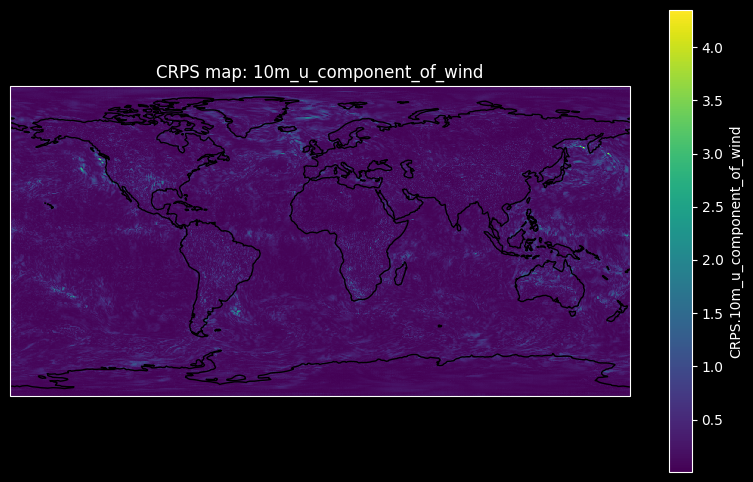

In [10]:
# Compute and plot a CRPS map using WeatherBenchX (reduce over time, keep lat/lon)
# Determine base variable to plot from cfg or available variables
cfg_plot_var = (
    cfg.get("plotting", {}).get("map_variable")
    if isinstance(cfg, dict)
    else None
)
if cfg_plot_var and cfg_plot_var.startswith("CRPS."):
    base_var = cfg_plot_var.split(".", 1)[1]
elif cfg_plot_var:
    base_var = cfg_plot_var
else:
    # fallback: use the first variable that exists in both datasets
    common = [v for v in ds_predictions.data_vars if v in ds_targets.data_vars]
    if not common:
        raise ValueError(
            "No common variables between ds_predictions and ds_targets for map plot."
        )
    base_var = common[0]

# Build a time-only aggregator (keep spatial dims)
reduce_dims = [
    d
    for d in ["init_time", "lead_time", "time"]
    if d in ds_predictions[base_var].dims
]
map_aggregator = aggregation.Aggregator(reduce_dims=reduce_dims)

# Compute CRPS map for the chosen variable
metrics_map = {"CRPS": CRPSEnsemble(ensemble_dim="ensemble")}
pred_map = {base_var: ds_predictions[base_var]}
targ_map = {base_var: ds_targets[base_var]}
map_ds = aggregation.compute_metric_values_for_single_chunk(
    metrics_map, map_aggregator, pred_map, targ_map
)

crps_name = f"CRPS.{base_var}"
if crps_name not in map_ds:
    raise KeyError(
        f"Expected {crps_name} in computed map dataset, got {list(map_ds.data_vars)}"
    )
mean_map = map_ds[crps_name]

# Detect latitude/longitude coordinate names
lat_name = next(
    (n for n in mean_map.dims if n in ("latitude", "lat", "y")), None
)
lon_name = next(
    (n for n in mean_map.dims if n in ("longitude", "lon", "x")), None
)
if lat_name is None or lon_name is None:
    raise ValueError(f"Cannot find lat/lon dims in {mean_map.dims}")

# Ensure latitude is ascending for pcolormesh
lat_vals = mean_map[lat_name].values
if lat_vals[0] > lat_vals[-1]:
    mean_map = mean_map.sortby(lat_name)

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
lon = mean_map[lon_name].values
lat = mean_map[lat_name].values
mesh = ax.pcolormesh(lon, lat, mean_map.values, cmap="viridis", shading="auto")
plt.colorbar(mesh, ax=ax, orientation="vertical", label=crps_name)
ax.set_title(f"CRPS map: {base_var}")
plt.show()

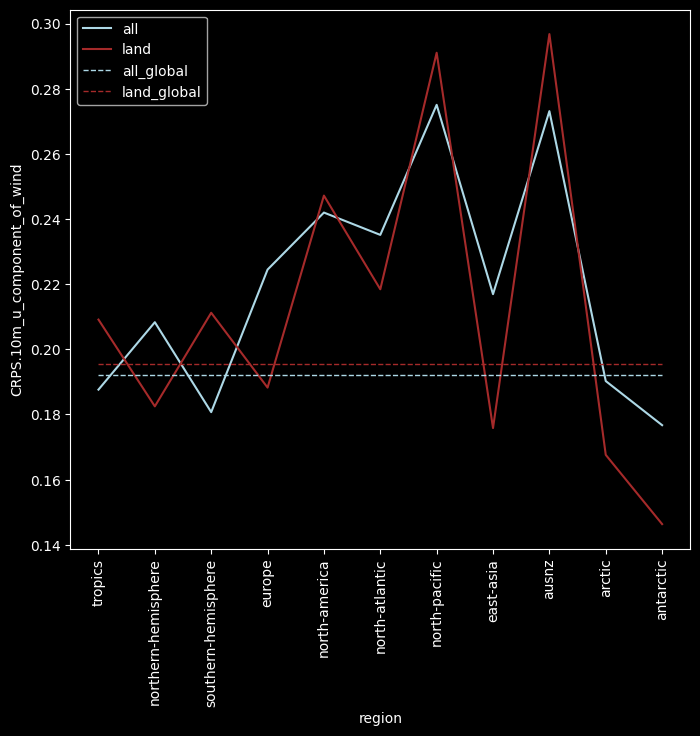

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))
land = temporal_results.mean(["init_time", "lead_time"])[
    "CRPS.10m_u_component_of_wind"
].sel(
    region=[r.item() for r in temporal_results["region"] if "_land" in r.item()]
)
full = temporal_results.mean(["init_time", "lead_time"])[
    "CRPS.10m_u_component_of_wind"
].sel(
    region=[
        r.item() for r in temporal_results["region"] if "_land" not in r.item()
    ]
)
# temporal_results.mean(["init_time"])
land = land.assign_coords(region=[r.item() for r in full["region"]])

# orientation of xlabels must be vertical
full[1:].plot(ax=ax, label="all", color="lightblue")
land[1:].plot(ax=ax, label="land", color="brown")
ax.hlines(
    full[0].values,
    0,
    len(full["region"][1:]) - 1,
    ls="--",
    ec="lightblue",
    lw=1,
    label="all_global",
)
ax.hlines(
    land[0].values,
    0,
    len(land["region"][1:]) - 1,
    ls="--",
    ec="brown",
    lw=1,
    label="land_global",
)
plt.xticks(rotation=90)
plt.legend()
# temporal_results
# [r.item() for r in temporal_results["region"]]